### README

Plots from rMATS results (overexpression of C* factors mutants):
- summary barplot
- volcano plot
- Venn diagram

### Requirements

In [1]:
# Python libraries
"""
pandas==2.2.3
numpy==2.0.2
matplotlib==3.10.0
matplotlib-venn==1.1.2
"""

'\npandas==2.2.3\nnumpy==2.0.2\nmatplotlib==3.10.0\nmatplotlib-venn==1.1.2\n'

In [1]:
#dataframe
import pandas as pd
import numpy as np

#plot
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3

#os
import os

### Constants

In [ ]:
# Input: rMATS results
# this is a folder where subfolders are named by the comparisons: condition1_VS_condition2
RMATS_PATH = '/PATH/TO/RMATS' 
MODE = 'JCEC'
EVENT_LIST = ['A3SS', 'RI']    
COMPARISON_SEPARATOR = '_VS_'

# Output: set directory
OUTPUT_PATH = '/PATH/TO/OUTPUT'

### Functions

##### Get rMATS results

In [3]:
# SUPPORTING FUNCTIONS TO RETRIEVE AND PROCESS rMATS RESULTS

#--------------------------------------------
# Get event parameters based on event type
def get_event_params(eventType):
    event_params = {
        "A3SS": (
            ['shortES', 'longExonStart_0base'],
            ['longExonEnd', 'shortEE'],
            ['geneSymbol', 'chr', 'strand', 'longExonStart_0base', 'longExonEnd', 'shortES', 'shortEE', 'flankingES', 'flankingEE']
        ),
        "A5SS": (
            ['longExonEnd', 'shortEE'],
            ['shortES', 'longExonStart_0base'],
            ['geneSymbol', 'chr', 'strand', 'longExonStart_0base', 'longExonEnd', 'shortES', 'shortEE', 'flankingES', 'flankingEE']
        ),
        "RI": (
            ['downstreamES', 'upstreamEE'],
            ['downstreamES', 'upstreamEE'],
            ['geneSymbol', 'chr', 'strand', 'riExonStart_0base', 'riExonEnd', 'upstreamES', 'upstreamEE', 'downstreamES', 'downstreamEE']
        ),
        "SE": (
            ['exonEnd', 'exonStart_0base'],
            ['exonEnd', 'exonStart_0base'],
            ['geneSymbol', 'chr', 'strand', 'exonStart_0base', 'exonEnd', 'upstreamES', 'upstreamEE', 'downstreamES', 'downstreamEE']
        )
    }
    return event_params.get(eventType, ([], [], []))


#--------------------------------------------
# Calculate distance based on strand
def calculate_distance(df, true_list, false_list):
    df['Distance'] = np.where(df['strand'] == '+', df[true_list[0]] - df[true_list[1]], df[false_list[0]] - df[false_list[1]])
    return df


#--------------------------------------------
# Calculate mean counts
def read_counts(df, sample_number='1'):

    total = pd.Series(0.0, index=df.index)

    for col_prefix in ['IJC_SAMPLE_', 'SJC_SAMPLE_']:
        col = df[f'{col_prefix}{sample_number}'].astype(str)

        total += col.str.split(',').apply(lambda x: np.nanmean(pd.to_numeric(x, errors='coerce')))

    return total


In [4]:
# GET rMATS RESULTS

def get_rmats_results(
    eventType_list: list[str],
    rmats_path: list[str],
    comparison_list: list[str],
    
    ):
    
    rmats_dict = {}
    for comparison in comparison_list:
        rmats_dict[comparison] = {}
        for eventType in eventType_list:
            # Get event ID column list
            true_list, false_list, col_list = get_event_params(eventType)
            rmats_df = pd.read_table(f'{rmats_path}/{comparison}/{eventType}.MATS.{MODE}.txt')
            # Calculate distance
            rmats_df = calculate_distance(rmats_df, true_list, false_list)
            # Calculate read counts for samples 1 and 2
            rmats_df['MeanCounts_SAMPLE_1'] = read_counts(rmats_df, sample_number='1')
            rmats_df['MeanCounts_SAMPLE_2'] = read_counts(rmats_df, sample_number='2')
    
            # Create unique event ID from col_list
            rmats_df['event_id'] = rmats_df[col_list+['Distance']].astype(str).agg('_'.join, axis=1)
            
            rmats_dict[comparison][eventType] = rmats_df.copy()

    return rmats_dict

##### Plots

In [5]:
 # SUMMARY BARPLOT

def plot_event_summary_bar(
    eventType: str,
    df_dict: dict[str, dict[str, pd.DataFrame]],
    comparison_list: list[str],
    reads_min: int = 10,
    stats_col: str = "FDR",
    stats_min: float = 0.01,
    diff_col: str = "IncLevelDifference",
    diff_min: float = 0.0,
    distance_range: tuple | None = None, # both values inclusive
    figsize: tuple = (6, 4),
    bar_width: float =- 0.2,
    xlim: tuple | None = None,
    title: str | None = None,
    colourleft: str = 'silver',
    colourright:str = 'yellow',
    edgecolorleft: str = 'darkgray',
    edgecolorright: str = 'gold',
    save_file: str | None = None
    ):

    summary_dict = {}

    for comparison in comparison_list:
        conditions = comparison.split(COMPARISON_SEPARATOR)
        df = df_dict[comparison][eventType].copy()
    

        # Apply filters
        df = df[
            (df[stats_col] <= stats_min) &
            (df[diff_col].abs() >= diff_min) &
            (df["MeanCounts_SAMPLE_1"] >= reads_min) &
            (df["MeanCounts_SAMPLE_2"] >= reads_min)
        ]


        if distance_range:
            df = df[(df['Distance'] >= distance_range[0]) & (df['Distance'] <= distance_range[1])]

        higher1_n = df[df[diff_col]>0].shape[0]
        higher2_n = df[df[diff_col]<0].shape[0]
    
        summary_dict[f"{conditions[0]} vs {conditions[1]}"] = [higher1_n, higher2_n]
            
        
    # Prepare data for plotting
    higher1 = [summary_dict[comparison][0] for comparison in summary_dict]
    higher2 = [summary_dict[comparison][1] for comparison in summary_dict]

    y = np.arange(len(summary_dict.keys()))  # Positions for the event types on the y-axis.
    
    # Create the horizontal mirror bar plot:
    plt.figure(figsize=figsize)

    # Plot de novo counts (on the right side).
    plt.barh(y - 0.01 * bar_width, [-val for val in higher1], bar_width, label='incl.', color=colourleft, alpha=1, edgecolor=edgecolorleft, linewidth=1.5)
    plt.barh(y - 0.01 * bar_width, higher2, bar_width, label='skip.', color=colourright, alpha=1, edgecolor=edgecolorright, linewidth=1.5)
    # Add labels, legend, and title to the plot.
    plt.ylabel('Event Type')  # Label for the y-axis.
    plt.xlabel('Number of Events')  # Label for the x-axis.
    plt.title(title)  # Title of the plot.
    plt.yticks(y, summary_dict.keys())  # Set the y-axis ticks to the event types.
    plt.axvline(0, color='black', linewidth=0.8)  # Add a vertical line at x=0 for clarity.
    plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)

    
    # Adjust x-axis ticks to show positive values only.
    if xlim:
        plt.xlim(xlim)
    else:
        max_val = max(max(higher1), max(higher2))
        max_val = max_val + 5-(max_val%5)
        plt.xticks(np.arange(-max_val, max_val+6, step=max_val // 5), [abs(tick) for tick in np.arange(-max_val, max_val+6, step=max_val // 5)])
        plt.xlim(-max_val-5, max_val+5)

    # Add custom legend labels.
    plt.legend(bbox_to_anchor=(0.3, -0.1))  # Add a legend to distinguish the bars.
    
    # Remove upper and right axis lines for a cleaner look.
    plt.gca().spines['right'].set_visible(False)  # Hide the right axis line.
    plt.gca().spines['top'].set_visible(False)  # Hide the top axis line.
    
    # Show the plot:
    # Adjust layout to prevent clipping and display the plot.
    
    plt.tight_layout()
    if save_file:
        plt.savefig(save_file, bbox_inches='tight')

    plt.show()

In [6]:
# VOLCANO PLOT

def plot_event_volcano(
    df: pd.DataFrame,
    comparison: str,
    eventType: str,
    distance_range: tuple | None = None, # both values included
    read_min: int = 10,
    y_col: str = "FDR",
    y_threshold: float = 0.01,
    x_col: str = "IncLevelDifference",
    x_threshold: float = 0.0,
    positive_colour: str = "cornflowerblue",
    negative_colour: str = "indianred",
    figsize: tuple = (6, 6),
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    title: str | None = None, 
    save_file: str | None = None):
    
    
    conditions = comparison.split(COMPARISON_SEPARATOR)

    df = df.copy()
    df = df[(df['MeanCounts_SAMPLE_1'] >= read_min)&(df['MeanCounts_SAMPLE_2'] >= read_min)]
    if distance_range:
        df = df[(df['Distance'] >= distance_range[0]) & (df['Distance'] <= distance_range[1])] 
    df = df.dropna(subset=[y_col, x_col]).copy()
    df.loc[df[y_col] == 0, y_col] = 1e-20 #set very small value for zero p-values to avoid log10 issues
    df["neg_log10_y"] = -np.log10(df[y_col])
    
    # Assign colors
    def volcano_color(row): 
        if row[y_col] <= y_threshold:
            if row[x_col] >= x_threshold:
                return positive_colour
            elif row[x_col] <= -x_threshold:
                return negative_colour
        return "lightgray"
    
    df["colour"] = df.apply(volcano_color, axis=1)

    # Plot
    plt.figure(figsize=figsize)
    plt.scatter(
        df[x_col],
        df["neg_log10_y"],
        c=df["colour"],
        alpha=0.7,
        edgecolors=None,
        s=30
    )

    # Threshold lines
    plt.axhline(-np.log10(y_threshold), color="black", linestyle="--", linewidth=1)
    plt.axvline(-x_threshold, color="black", linestyle="--", linewidth=1)
    plt.axvline(x_threshold, color="black", linestyle="--", linewidth=1)

    # Labels and style
    plt.xlabel(f"{x_col} ({conditions[0]} - {conditions[1]})")
    plt.ylabel(f"-log10({y_col})")
    if not title:
        title = f"{conditions[0]} vs {conditions[1]} ({eventType})"
        if distance_range:
            title += f" (Distance {distance_range[0]}-{distance_range[1]})"
    plt.title(title)
    if ylim:
        plt.ylim(ylim)
    if xlim:
        plt.xlim(xlim)
    else:
        plt.xlim(-1,1)
    plt.grid(True)
    plt.tight_layout()

    if save_file:
        plt.savefig(save_file, bbox_inches='tight')

    plt.show()


In [7]:
# VENN DIAGRAM

def plot_venn(
    eventType: str,
    df_dict: dict[str, dict[str, pd.DataFrame]],
    comparison_list: list[str],
    reads_min: int = 10,
    stats_col: str = "FDR",
    stats_min: float = 0.01,
    diff_col: str = "IncLevelDifference",
    diff_min: float = 0.0,
    diff_direction: str = 'both', # 'higher1', 'higher2' or 'both'
    distance_range: tuple | None = None, # both values inclusive
    figsize: tuple = (6, 6),
    title: str | None = None,
    save_file: str | None = None
    ):



    set_list = []
    for comparison in comparison_list:
        
        df = df_dict[comparison][eventType]
        df = df[
            (df[stats_col] <= stats_min) &
            (df[diff_col].abs() >= diff_min) &
            (df['MeanCounts_SAMPLE_1'] >= reads_min) &
            (df['MeanCounts_SAMPLE_2'] >= reads_min)
        ]

        if diff_direction == 'higher1':
            df = df[df[diff_col] > 0]
        elif diff_direction == 'higher2':
            df = df[df[diff_col] < 0]
  

        if distance_range:
            df = df[(df['Distance'] >= distance_range[0]) & (df['Distance'] <= distance_range[1])]

        event_set = set(df['event_id'])
        set_list.append(event_set)
    # Create a Venn diagram
    plt.figure(figsize=figsize)
    if len(set_list) == 2:
        venn2(subsets=set_list, set_labels=comparison_list)
    elif len(set_list) == 3:
        venn3(subsets=set_list, set_labels=comparison_list)
    else:
        raise ValueError("Only 2 or 3 comparisons are supported for Venn diagrams.")
    plt.title(title)
    if save_file:
        plt.savefig(save_file, bbox_inches='tight')
    plt.show()


### Analysis

##### 1. Get rMATS results

In [8]:
comparison_list = os.listdir(RMATS_PATH)

conditions_list = list({cond for folder in comparison_list for cond in folder.split(COMPARISON_SEPARATOR)})

In [9]:
# get rmats results
rmats_dict = get_rmats_results(
    rmats_path = RMATS_PATH,
    comparison_list = comparison_list,
    eventType_list = EVENT_LIST)

In [ ]:
# save significant events for each comparison 
# NAGNAG
for comparison in comparison_list:
    df = rmats_dict[comparison]['A3SS'].copy()
    df = df[
        (df["FDR"] <= 0.01) &
        (df["IncLevelDifference"].abs() >= 0.0) &
        (df["MeanCounts_SAMPLE_1"] >= 10) &
        (df["MeanCounts_SAMPLE_2"] >= 10) &
        (df['Distance'] == 3)
    ]
    df.to_csv(f"{OUTPUT_PATH}/{comparison}_NAGNAG_significant_events.csv", index=False)


# RI
for comparison in comparison_list:
    df = rmats_dict[comparison]['RI'].copy()
    df = df[
        (df["FDR"] <= 0.01) &
        (df["IncLevelDifference"].abs() >= 0.15) &
        (df["MeanCounts_SAMPLE_1"] >= 10) &
        (df["MeanCounts_SAMPLE_2"] >= 10) 
    ]
    df.to_csv(f"{OUTPUT_PATH}/{comparison}_RI_significant_events.csv", index=False)

##### 2. Summary barplot of significant events

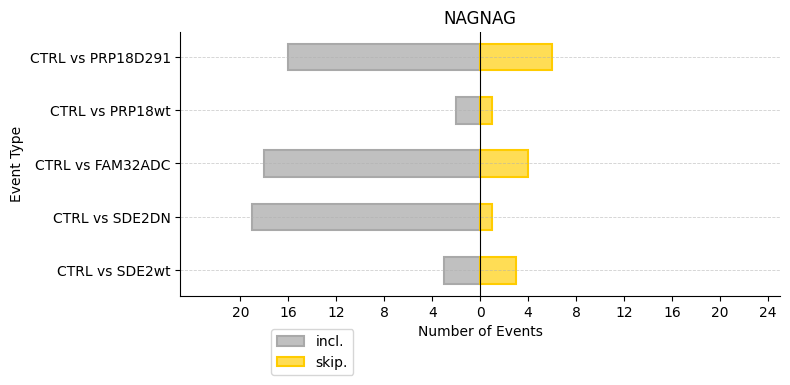

In [11]:
# NAGNAG summary barplot
plot_event_summary_bar(
    df_dict= rmats_dict,
    comparison_list = ['CTRL_VS_SDE2wt', 'CTRL_VS_SDE2DN', 
                   'CTRL_VS_FAM32ADC',
                   'CTRL_VS_PRP18wt', 'CTRL_VS_PRP18D291' ],
    eventType = 'A3SS',
    diff_col='IncLevelDifference',
    diff_min=0.0,
    reads_min = 10,
    stats_col = 'FDR',
    stats_min = 0.01,
    bar_width=0.5,
    colourright='#ffdd55ff',
    edgecolorright='#ffcc00ff',
    distance_range=(3,3),
    save_file=f'{OUTPUT_PATH}/summarybar_NAGNAG.svg',
    title='NAGNAG',
    figsize=(8,4))

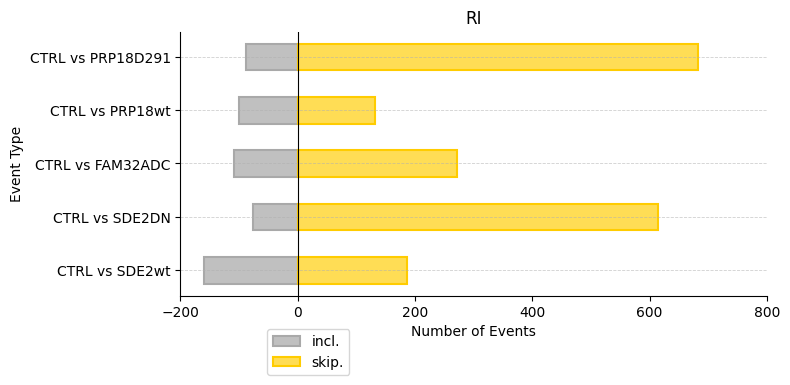

In [12]:
# RI summary barplot
plot_event_summary_bar(
    df_dict= rmats_dict,
    eventType= 'RI',
    comparison_list=['CTRL_VS_SDE2wt', 'CTRL_VS_SDE2DN', 
                   'CTRL_VS_FAM32ADC',
                   'CTRL_VS_PRP18wt', 'CTRL_VS_PRP18D291' ],
    diff_col='IncLevelDifference',
    diff_min=0.15,
    reads_min = 10,
    stats_col = 'FDR',
    stats_min = 0.01,
    bar_width=0.5,
    xlim=(-200,800),
    colourright='#ffdd55ff',
    edgecolorright='#ffcc00ff',
    save_file=f'{OUTPUT_PATH}/summarybar_RI.svg',
    title='RI',
    figsize=(8,4))

##### 3. Volcano plot

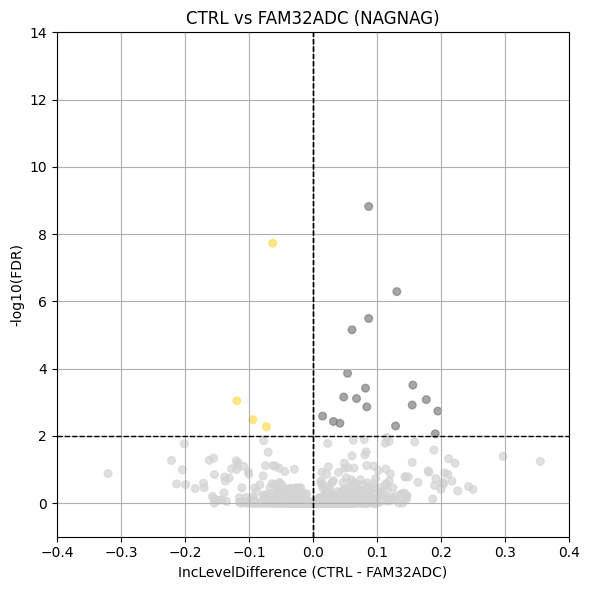

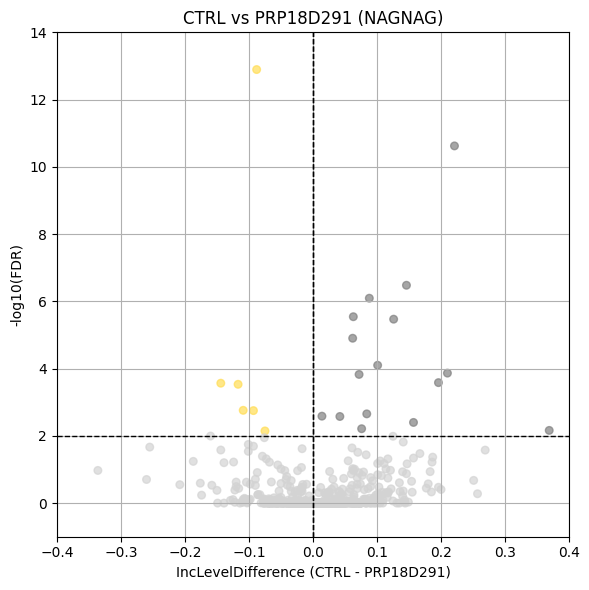

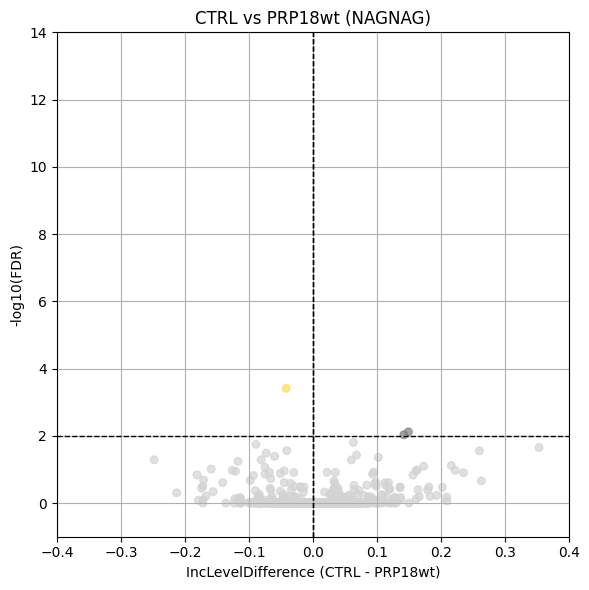

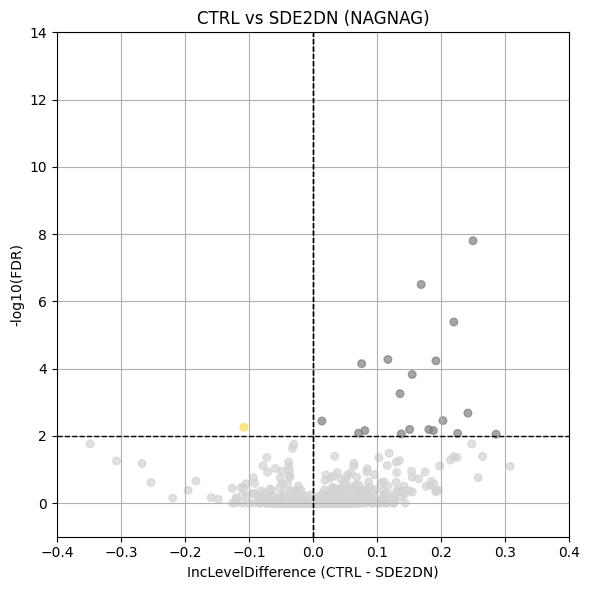

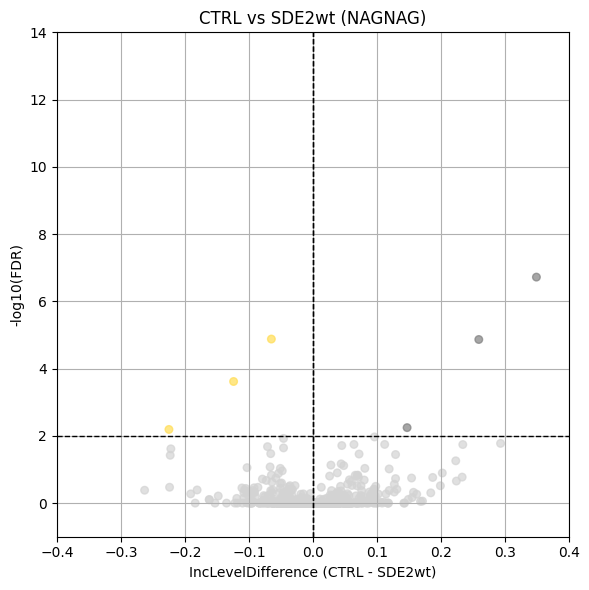

In [13]:
# NAGNAG volcano plot
eventType = 'A3SS'
for comparison in comparison_list:
    plot_event_volcano(
        df=rmats_dict[comparison][eventType],
        comparison=comparison,
        eventType=eventType,
        distance_range=(3,3),
        x_threshold=0.0,
        y_threshold=0.01,
        read_min=10,
        xlim=(-0.4,0.4),
        ylim=(-1,14),
        positive_colour ='grey',
        negative_colour= "#ffdd55ff",
        title=f"{comparison.replace(COMPARISON_SEPARATOR, ' vs ')} (NAGNAG)",
        save_file=f'{OUTPUT_PATH}/volcano_{comparison}_NAGNAG.svg'

    )

    

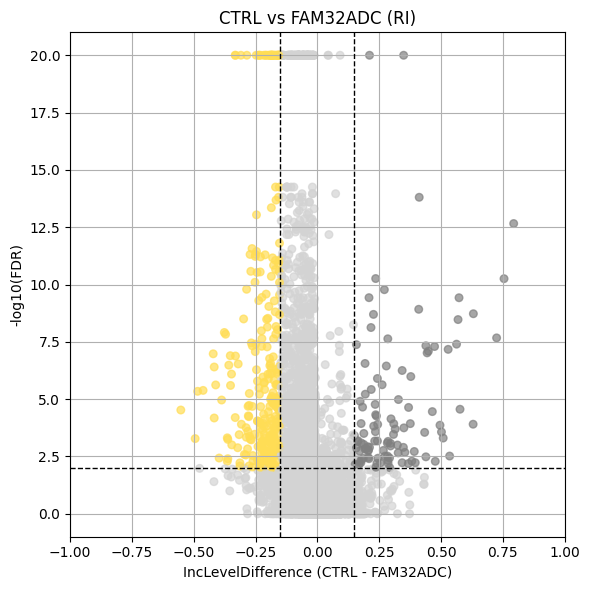

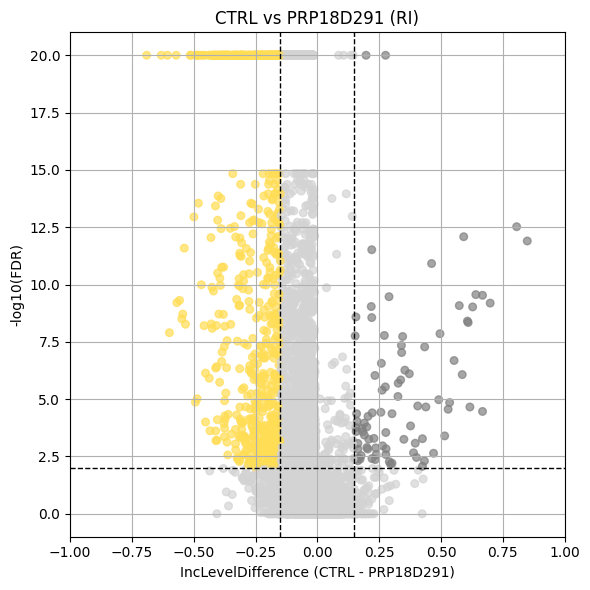

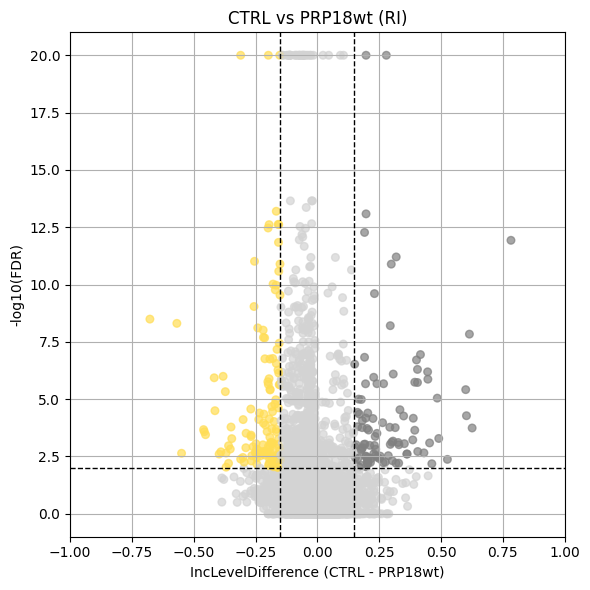

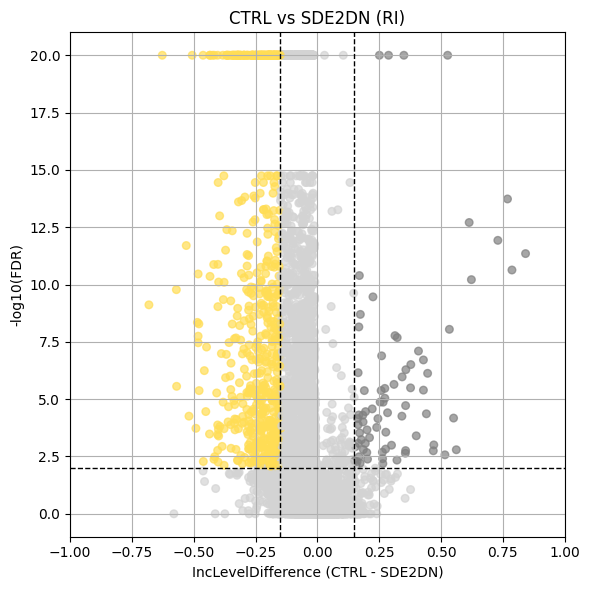

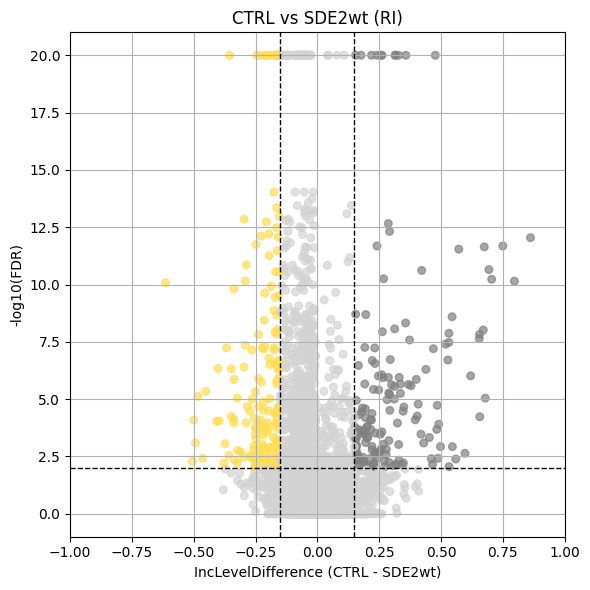

In [14]:
# RI volcano plot
eventType = 'RI'
for comparison in comparison_list:
    plot_event_volcano(
        df=rmats_dict[comparison][eventType],
        comparison=comparison,
        eventType=eventType,
        x_threshold=0.15,
        y_threshold=0.01,
        read_min=10,
        positive_colour = 'grey',
        negative_colour ="#ffdd55ff",
        save_file=f'{OUTPUT_PATH}/volcano_{comparison}_{eventType}.svg',
    )

    

##### 4. Venn diagram of significant events

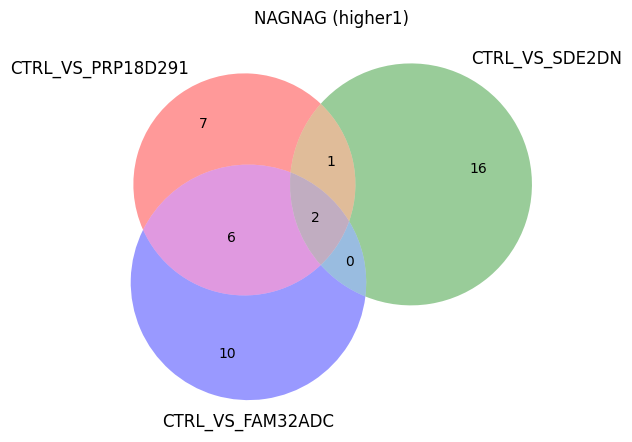

In [15]:
# NAGNAG Venn diagram
plot_venn(
    eventType = 'A3SS',
    df_dict = rmats_dict,
    comparison_list = ['CTRL_VS_PRP18D291', 
                   'CTRL_VS_SDE2DN',
                   'CTRL_VS_FAM32ADC'],
    diff_min=0.0,
    reads_min = 10,
    stats_col = 'FDR',
    stats_min = 0.01,
    diff_col = "IncLevelDifference",
    diff_direction = 'higher1',
    distance_range=(3,3),
    title='NAGNAG (higher1)',
    save_file=f'{OUTPUT_PATH}/venn_NAGNAG.svg'
)

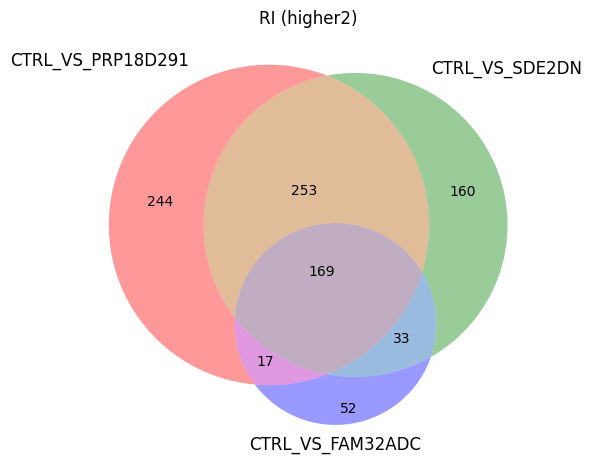

In [16]:
# RI Venn diagram
plot_venn(
    eventType = 'RI',
    df_dict = rmats_dict,
    comparison_list = ['CTRL_VS_PRP18D291', 
                   'CTRL_VS_SDE2DN',
                   'CTRL_VS_FAM32ADC'],
    diff_min=0.15,
    reads_min = 10,
    stats_col = 'FDR',
    stats_min = 0.01,
    diff_col = "IncLevelDifference",
    diff_direction = 'higher2',
    title='RI (higher2)',
    save_file=f'{OUTPUT_PATH}/venn_RI.svg'
)